# Agent Quality

### Four pillars of Agent Quality

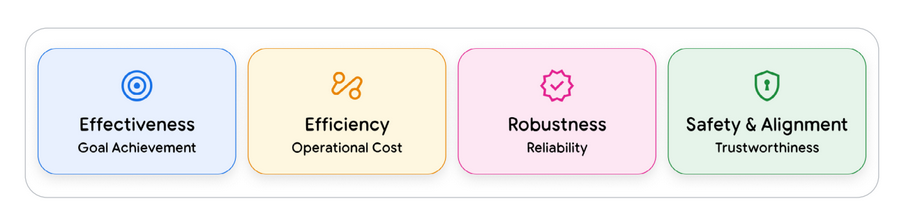

- Effectiveness (Goal Achievement): This pillar assesses whether the agent successfully and accurately met the user's actual intent. Rather than just measuring technical success (like finding a product), it focuses on high-level outcomes such as conversion rates or providing correct insights from data.

- Efficiency (Operational Cost): This measures how well an agent solved a problem in terms of resources consumed. It tracks the total tokens used (cost), latency (wall-clock time), and trajectory complexity (the number of steps and self-correction loops taken to complete a task).

- Robustness (Reliability): This pillar evaluates how an agent handles adversity and real-world messiness, such as API timeouts, missing data, or ambiguous prompts. A robust agent should fail gracefully, ask for clarification when needed, or report specific issues rather than crashing or hallucinating.

- Safety & Alignment (Trustworthiness): Considered a non-negotiable gate, this pillar ensures the agent operates within ethical boundaries and organizational constraints. It encompasses metrics for fairness, bias, and security against threats like prompt injection or data leakage.

### Evaluation

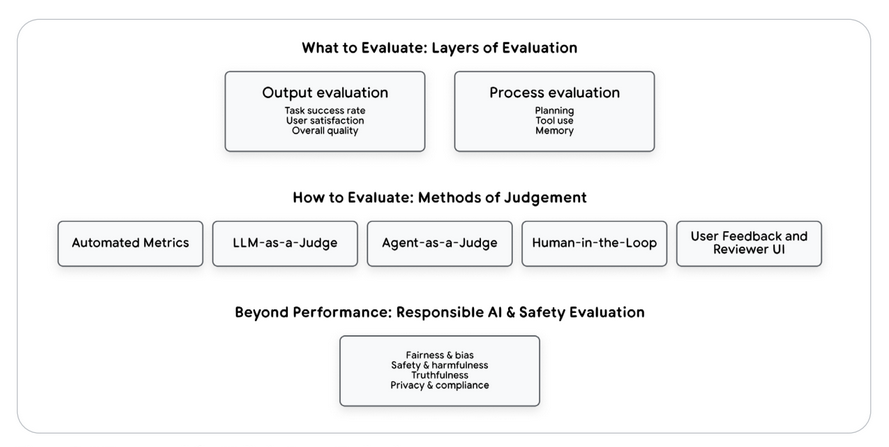

Outside-In evaluation is a top-down strategic framework that shifts the focus of agent assessment from internal technical scores to user-centric metrics and real-world business goals. This approach is necessitated by the non-deterministic nature of AI agents, where traditional verification (did we build the product right?) must be replaced by validation (did we build the right product?).

The framework is structured as a two-stage hierarchy that starts with the "black box" and then opens it up:

**1. End-to-End Evaluation (The Black Box)**

The first priority is the "Outside-In" view, which asks whether the agent achieved the user's actual intent regardless of its internal steps. This stage measures measurable value and alignment through specific metrics:

- Task Success Rate: A binary or graded score of whether the final problem was solved (e.g., a successful database transaction or session completion).

- User Satisfaction: Direct feedback such as thumbs up/down or Customer Satisfaction Scores (CSAT).

- Overall Quality: Qualitative or quantitative assessments of the final output, such as the accuracy of a summary.

**2. Trajectory Evaluation (The Glass Box)**

If the "Black Box" view identifies a failure or inefficiency, the evaluator moves to the "Inside-Out" view to analyze the agent's decision-making trajectory. This involves systematically checking:
- LLM Planning: Detecting hallucinations or repetitive loops in the "thought" process.

- Tool Usage: Verifying if the agent selected the correct tools and provided valid parameters.

- Response Interpretation: Ensuring the agent correctly understood tool outputs or error states (e.g., a 404 error).

- Efficiency and Robustness: Identifying excessive API calls, high latency, or failures to handle environmental messiness.

- RAG Performance: Identifying irrelevant document retrieval, fetching outdated or incorrect information, or the LLM ignoring the retrieved context entirely and hallucinating an answer anyway.

- Multi-Agent Dynamics: Include inter-agent communication logs to check for misunderstandings or communication loops and ensure agents are adhering to their defined roles without conflicting with others.

**Key Strategic Importance**

Trajectory is the truth; because a correct final answer can be reached through a flawed or unsafe process, the Outside-In framework demands deep visibility into every step the agent takes. By prioritizing real-world success before diving into technical details, organizations can avoid getting lost in component-level metrics and focus on building trustworthy and reliable systems.

This framework eventually feeds into the "Agent Quality Flywheel," where production failures identified through this process are converted into permanent regression tests to drive continuous improvement

### Evaluators

To evaluate autonomous agents, the sources describe a hybrid approach that combines scalable, automated systems with the indispensable, nuanced judgment of humans. 

Evaluators are categorized based on their role in assessing either the final output (the "Black Box") or the internal decision-making process (the "Glass Box").

The primary evaluators used are detailed below:

1. **Automated Metrics**

These provide speed and reproducibility, making them ideal as the first quality gate in a CI/CD pipeline.

- String-based similarity: Measures like ROUGE and BLEU compare generated text to reference answers.

- Embedding-based similarity: Metrics such as BERTScore measure semantic closeness rather than just exact word matches.

- Task-specific benchmarks: Tools like TruthfulQA are used to measure specific traits like factuality.

2. **LLM-as-a-Judge**

This paradigm uses a powerful, state-of-the-art model (such as Google’s Gemini Advanced) to evaluate the outputs of another agent.

- Methodology: The "judge" LLM is provided with the agent's output, the original prompt, and a detailed rubric to score helpfulness, correctness, and safety.

- Pairwise Comparison: The sources recommend having the judge compare two different agent versions (Answer A vs. Answer B) to calculate a win/loss/tie rate, which is often a more reliable signal than absolute scores.

3. **Agent-as-a-Judge**

While LLMs score final responses, this evaluator uses a specialized "Critic Agent" to assess the full execution trace (the process) of another agent. It focuses on:

- Plan Quality: Was the initial plan logical and feasible?

- Tool Use: Were the correct tools chosen and arguments formatted properly?

- Context Handling: Did the agent effectively use prior information?

4. **Human-in-the-Loop (HITL)**

Humans remain the ultimate arbiter of quality, as they are essential for capturing qualitative signals that automated systems miss.

- Domain Expertise: Experts are used to verify factual correctness in specialized fields like medicine or law.

- The "Golden Set": Humans are responsible for curating the high-quality benchmark datasets used to train and calibrate automated evaluators.

- Interruption Workflows: For high-stakes actions (like executing payments), humans may act as a runtime evaluator, approving or rejecting steps before the agent proceeds.

5. **User Feedback**

Real-world performance is evaluated through direct signals from users, such as:

- Explicit Feedback: Thumbs up/down or Customer Satisfaction Scores (CSAT).

- In-product Success Metrics: Quantitative data such as pull request (PR) acceptance rates for coding agents or successful booking rates for travel agents.

6. **Safety & Responsible AI Evaluators**

Safety evaluation is a non-negotiable gate that uses specialized techniques:

- Systematic Red Teaming: Adversarial evaluators who actively try to break the agent to find vulnerabilities like prompt injection or bias.

- Safety Classifiers: Automated filters that scan inputs for malicious intent and outputs for PII (Personally Identifiable Information) leakage.

### Obesrvability

Observability is the foundational architectural pillar that allows developers to see inside the agent’s "mind" to understand its decision-making process. While traditional monitoring verifies if a predictable system is running according to a checklist, observability focuses on validating the quality of an agent's cognitive processes—asking not just if the agent is running, but if it is thinking effectively.

The three pillars of observability that provide this insight are Logging, Tracing, and Metrics:

**1. Logging (The Agent's Diary)**

Logs are the atomic units of observability, consisting of raw, immutable, and timestamped records of discrete events. They answer the question of "what happened" at any given moment, such as an agent deciding to use a specific tool.

- Effectiveness: For logs to be useful, they should be structured (ideally in JSON) and rich with context, capturing prompt/response pairs, the agent's "chain of thought," and tool execution details.

- Pattern: A powerful practice is to log the agent's intent before an action and the outcome afterward to distinguish between a failed attempt and a deliberate decision not to act.

**2. Tracing (Following the Agent's Footsteps)**

If logs are individual diary entries, traces are the narrative thread that connects them into a coherent story. Tracing follows a single task from the initial user query to the final response, revealing the causal relationship between events.

- Indispensability: Tracing is vital for root cause analysis. For example, if an agent provides a nonsensical answer, isolated logs might only show an error, but a trace can reveal that the failure started with a faulty RAG search that passed null input to a tool, which then confused the LLM.

- Standards: Modern tracing is often built on OpenTelemetry, using "spans" (individual operations) linked by a unique "trace_id".

**3. Metrics (The Agent's Health Report)**

Metrics are the quantitative, aggregated scores that provide an at-a-glance understanding of overall performance. They are not a separate data source but are derived by aggregating data from logs and traces over time to answer "how well" the agent performed on average. The sources divide metrics into two categories:

- System Metrics (Vital Signs): These measure operational health, such as latency (P50/P99), error rates, and operational costs like token consumption.

- Quality Metrics (Judging Decision-Making): These are second-order metrics that assess reasoning and output quality, such as factual accuracy, trajectory adherence (did it follow the ideal recipe?), and helpfulness.

Together, these three pillars transform raw data into actionable insights, enabling the "Agent Quality Flywheel" where every production failure is captured and used to improve the system.

### Agent Quality Flywheel

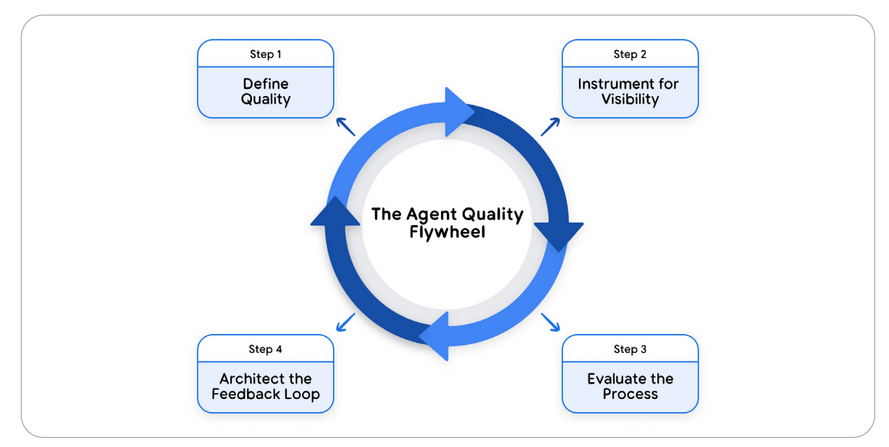

The Agent Quality Flywheel is an operational playbook and a self-reinforcing system designed to turn raw data into actionable insights for the continuous improvement of autonomous agents. It represents a synthesis of the entire evaluation and observability framework, serving as the mechanism that separates a clever demo from an enterprise-grade, trustworthy system.

The flywheel functions as a virtuous cycle where each push adds momentum to the system's reliability through four distinct steps:

**Step 1: Define Quality (The Target)**

The cycle begins by establishing clear, concrete targets based on the Four Pillars of Quality: Effectiveness, Cost-Efficiency, Robustness (Reliability), and Safety & Alignment.

**Step 2: Instrument for Visibility (The Foundation)**

Since it is impossible to manage what cannot be seen, the agent must be designed to emit structured Logs and end-to-end Traces. This observability provides the "rich evidence" or fuel needed to measure the pillars defined in the first step.

**Step 3: Evaluate the Process (The Engine)**

With visibility established, the system judges performance using the "Outside-In" approach. This is a hybrid engine that uses:

- Scalable LLM-as-a-Judge systems for speed and volume.

- Human-in-the-Loop (HITL) judgment to provide the "gold standard" for ground truth and nuanced alignment with human values.

**Step 4: Architect the Feedback Loop (The Momentum)**

This is the most critical stage for driving relentless improvement. In this step, production failures are captured, annotated, and programmatically converted into permanent regression tests within a "Golden" Evaluation Set. This ensures that every mistake the agent makes in the real world directly informs its future training and testing, making the system smarter with every iteration.

**Core Principles of the Flywheel**

There are three foundational principles that govern this flywheel:

- **Evaluation as an Architectural Pillar**: Reliable agents must be "evaluatable-by-design" from the first line of code, rather than having testing bolted on at the end.

- **The Trajectory is the Truth**: To understand why an agent succeeded or failed, one must analyze its entire "thought process" (the trajectory) rather than just the final answer.

- **The Human is the Arbiter**: While AI can help grade tests at scale, humans must write the rubrics and define what "good" actually means.